In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_cva.mc_benchmark.benchmark_utils import (
    simulate_S,
    price_grid_from_samples,
    discrete_probs_from_samples,
)
from quantum_cva.state_prep.qcbm.p_target import build_joint_target_from_P_bin

In [2]:
# Discretization parameters
n = 2
m = 2
N = 2**n  # number of price bins
M = 2**m  # number of time steps

In [ ]:
# ============================================================
# 0) Reproducibility
# ============================================================
np.random.seed(123)
 
# ============================================================
# 1) Simulate realistic S(t) paths
# ============================================================
S0 = 1.0
r = 0.02
sigma = 0.25

t = np.array([0.0, 0.25, 0.5, 1.0, 2.0], dtype=float)  # length M+1 => M=4

n_paths = 50_000
Z = np.random.standard_normal(size=(n_paths, M))

S_by_time = simulate_S(S0=S0, mu=r, sigma=sigma, t=t, Z=Z)

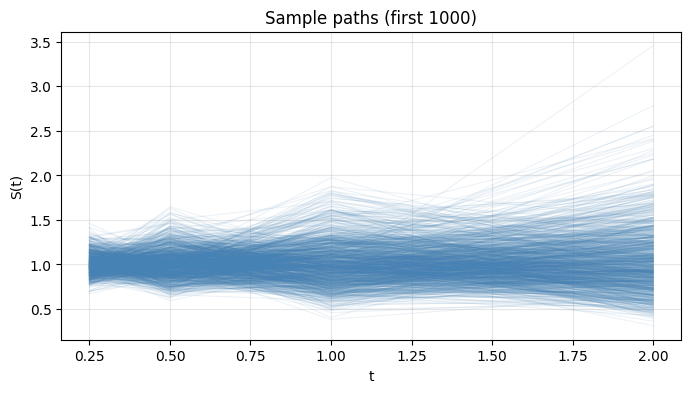

In [13]:
# Plot some sample paths and histogram at T
n_plot = 1000
S_plot = np.vstack([s[:n_plot] for s in S_by_time])

plt.figure(figsize=(8, 4))
for k in range(n_plot):
    plt.plot(t[1:], S_plot[:, k], color="steelblue", alpha=0.1, linewidth=0.8)
plt.title("Sample paths (first 1000)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# ============================================================
# 2) Discretize prices: choose n so that N=2^n bins (power of two)
# ============================================================
n_sigma = 3.0

edges, grid_info = price_grid_from_samples(S_by_time, n=n, n_sigma=n_sigma)
print("Grid info:", grid_info)
print("edges length:", len(edges), "=> N bins:", len(edges) - 1)
assert (len(edges) - 1) == N

Grid info: [ 27.29690449  81.89071346 136.48452243 191.07833141]
edges length: 5 => N bins: 4


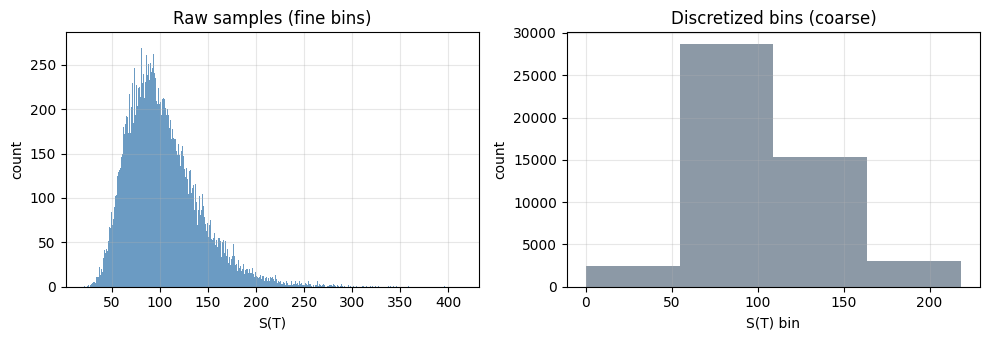

In [6]:
# ============================================================
# 2b) Histogram: raw vs discretized prices (loss of resolution)
# ============================================================
import matplotlib.pyplot as plt

t_idx = -1  # use final exposure date
samples = S_by_time[t_idx]

# Raw histogram (fine bins)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(samples, bins=1000, color="steelblue", alpha=0.8)
axes[0].set_title("Raw samples (fine bins)")
axes[0].set_xlabel("S(T)")
axes[0].set_ylabel("count")
axes[0].grid(True, alpha=0.3)

# Discretized histogram using the grid edges
counts, _ = np.histogram(samples, bins=edges)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
bin_widths = edges[1:] - edges[:-1]
axes[1].bar(bin_centers, counts, width=bin_widths, color="slategray", alpha=0.8, align="center")
axes[1].set_title("Discretized bins (coarse)")
axes[1].set_xlabel("S(T) bin")
axes[1].set_ylabel("count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# 3) Build conditional distributions P_bin[i,:] = P(s_bin | t_i)
# ============================================================
P_bin = np.zeros((M, N), dtype=float)
for i in range(M):
    P_bin[i, :] = discrete_probs_from_samples(S_by_time[i], edges)

assert P_bin.shape == (M, N)
assert np.all(P_bin >= -1e-15)
assert np.allclose(P_bin.sum(axis=1), 1.0, atol=1e-10)
print("P_bin OK. shape:", P_bin.shape)

P_bin OK. shape: (4, 4)


In [40]:
# ============================================================
# 4) Build joint target for QCBM (NO padding):
#    p_tg(i,j) = P(t_i) P(s_j|t_i), with uniform P(t_i)=1/M by default
# ============================================================
tgt = build_joint_target_from_P_bin(P_bin, order="time_major") 

print("\n--- Joint target summary ---")
print(f"M={tgt.M} (m={tgt.m} qubits), N={tgt.N} (n={tgt.n} qubits)")
print("len(p_tg) =", tgt.p_tg.size, "(expected M*N =", tgt.M * tgt.N, ")")
print("sum(p_tg) =", tgt.p_tg.sum())

assert tgt.M == M
assert tgt.N == N
assert tgt.p_tg.ndim == 1
assert tgt.p_tg.size == M * N
assert abs(tgt.p_tg.sum() - 1.0) < 1e-12


--- Joint target summary ---
M=4 (m=2 qubits), N=4 (n=2 qubits)
len(p_tg) = 16 (expected M*N = 16 )
sum(p_tg) = 1.0


Joint target distribution:
$$
p_{tg}(x),
$$
a flatten vector with $2^{n + m}$ elements. So the register $x$ is written in the computational basis of $n + m$ qubits.

In [41]:
# ============================================================
# Print all computational basis states directly from p_tg
# ============================================================
# Sanity check: check dimensions of tgt are correct
p = tgt.p_tg
m = tgt.m      # time qubits
n = tgt.n      # price qubits
M = tgt.M
N = tgt.N

def to_bits(x, L):
    return format(x, f"0{L}b")

print("Probability distribution over computational basis states (quantum - friendly):")

for x, prob in enumerate(p):
    # Binary representation of the full register
    bits = to_bits(x, m + n)

    # Decode indices according to time_major convention
    i = x // N          # time index
    j = x % N           # price-bin index

    bits_time  = bits[:m]
    bits_price = bits[m:]

    print(
        f"|{bits}>  "
        f"(t_{i+1}, s_{j})  "
        f"P = {prob:.6e}"
    )


Probability distribution over computational basis states (quantum - friendly):
|0000>  (t_1, s_0)  P = 0.000000e+00
|0001>  (t_1, s_1)  P = 1.915800e-01
|0010>  (t_1, s_2)  P = 5.841000e-02
|0011>  (t_1, s_3)  P = 1.000000e-05
|0100>  (t_2, s_0)  P = 8.000000e-05
|0101>  (t_2, s_1)  P = 1.749200e-01
|0110>  (t_2, s_2)  P = 7.441500e-02
|0111>  (t_2, s_3)  P = 5.850000e-04
|1000>  (t_3, s_0)  P = 2.106685e-03
|1001>  (t_3, s_1)  P = 1.606585e-01
|1010>  (t_3, s_2)  P = 8.202562e-02
|1011>  (t_3, s_3)  P = 5.209167e-03
|1100>  (t_4, s_0)  P = 1.210477e-02
|1101>  (t_4, s_1)  P = 1.449233e-01
|1110>  (t_4, s_2)  P = 7.749686e-02
|1111>  (t_4, s_3)  P = 1.547508e-02
